In [ ]:
"""CN7 labeled — 인덱스 0:375 구간, 선택 6개 컬럼 시계열.

노트북 셀에 그대로 붙여 넣거나 `python plot_cn7_idx0_375.py`로 실행합니다.
그림은 output/cn7_labeled_idx0_375.png에 저장되고, 노트북이면 셀 아래에 바로 표시됩니다.
"""
from pathlib import Path
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager

# ── 1. 데이터 파일 찾기 ─────────────────────────────────────────────
CANDIDATES = [
    'data/origin/moldset_labeled_cn7.csv',
    'kamp_data/moldset_labeled_cn7.csv',
    'moldset_labeled_cn7.csv',
    'cn7_labeled.csv',
]
search_roots = [Path.cwd(), *Path.cwd().parents, Path(r'D:\workspace\kamp')]
CSV = next((r / c for r in search_roots for c in CANDIDATES if (r / c).is_file()), None)
if CSV is None:
    raise FileNotFoundError('moldset_labeled_cn7.csv를 찾지 못했습니다. CSV 경로를 직접 지정하세요.')
ROOT = CSV.parents[2] if CSV.parent.name == 'origin' else CSV.parent
print('데이터:', CSV)

# ── 2. 한글 폰트 ────────────────────────────────────────────────────
names = {f.name for f in font_manager.fontManager.ttflist}
plt.rcParams['font.family'] = next((f for f in ['Malgun Gothic', 'NanumGothic', 'AppleGothic',
                                               'Noto Sans CJK KR', 'Noto Sans CJK JP'] if f in names), 'sans-serif')
plt.rcParams['axes.unicode_minus'] = False

# ── 3. 범위 먼저 제한 ──────────────────────────────────────────────
df = pd.read_csv(CSV, index_col=0)
columns = ['Plasticizing_Position', 'Max_Injection_Speed', 'Max_Back_Pressure',
           'Average_Back_Pressure', 'Mold_Temperature_3', 'Mold_Temperature_4']
d = df.iloc[0:375]
bad = d['PassOrFail'] == 1

# ── 4. 그리기 (y축은 제한된 구간의 최솟값~최댓값 + 8% 여백) ─────────
fig, axes = plt.subplots(len(columns), 1, figsize=(14, 2.3 * len(columns)), sharex=True)
for ax, col in zip(axes, columns):
    ax.plot(d.index, d[col], lw=1, color='#4C78A8')
    ax.scatter(d.index[bad], d.loc[bad, col], color='#E45756', s=25, zorder=3, label='불량(PassOrFail=1)')
    lo, hi = d[col].min(), d[col].max()
    pad = (hi - lo) * 0.08 or 0.1
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_ylabel(col, fontsize=9)
    ax.grid(alpha=0.3)
axes[0].legend(loc='upper right')
axes[-1].set_xlabel('인덱스')
axes[-1].set_xlim(0, 374)
fig.suptitle('CN7 labeled — 인덱스 0:375', y=1.0)
fig.tight_layout()

# ── 5. 저장 + 표시 ─────────────────────────────────────────────────
out = ROOT / 'output' / 'cn7_labeled_idx0_375.png'
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=130, bbox_inches='tight')
print('저장:', out)

# 커널에서 matplotlib.use('Agg')를 이미 실행했으면 plt.show()가 아무것도 안 그리므로
# 노트북에서는 저장한 PNG를 직접 표시합니다.
try:
    from IPython import get_ipython
    from IPython.display import Image, display
    if get_ipython() is not None:
        display(Image(filename=str(out)))
        plt.close(fig)
    else:
        raise ImportError
except ImportError:
    if matplotlib.get_backend().lower() != 'agg':
        plt.show()


hello world


## 결과보고서 v4 시각화

아래 셀만 실행하면 이 노트북에 해당하는 보고서 그림을 표시한다. 기존 학습·전처리·운영 셀을 다시 실행할 필요가 없다.
공통 생성 코드는 `reporting/visualizations.py`에 있다. 그림이 없으면 해당 코드를 먼저 실행한다.
고정 Test는 이미 관찰한 후속 평가이며, RF 연구 v1과 표준화 수정 후 v2를 구분한다.
시각화용 중앙값·IQR 변환은 표시 목적에 한정되며 모델 입력이나 기존 표준화 로직을 변경하지 않는다.


### CN7 원본 0–374행의 입력값과 불량 관측 위치

CN7 원본 부분집합 N=375 / 빨강=PassOrFail 1 / 시간축 아님 / 모델 없음

행 순서에 따른 값의 변화를 확인하였다. 생산시각이 없어 시간 추세, 공정 전환 또는 전후 관계로 확정할 수 없다.

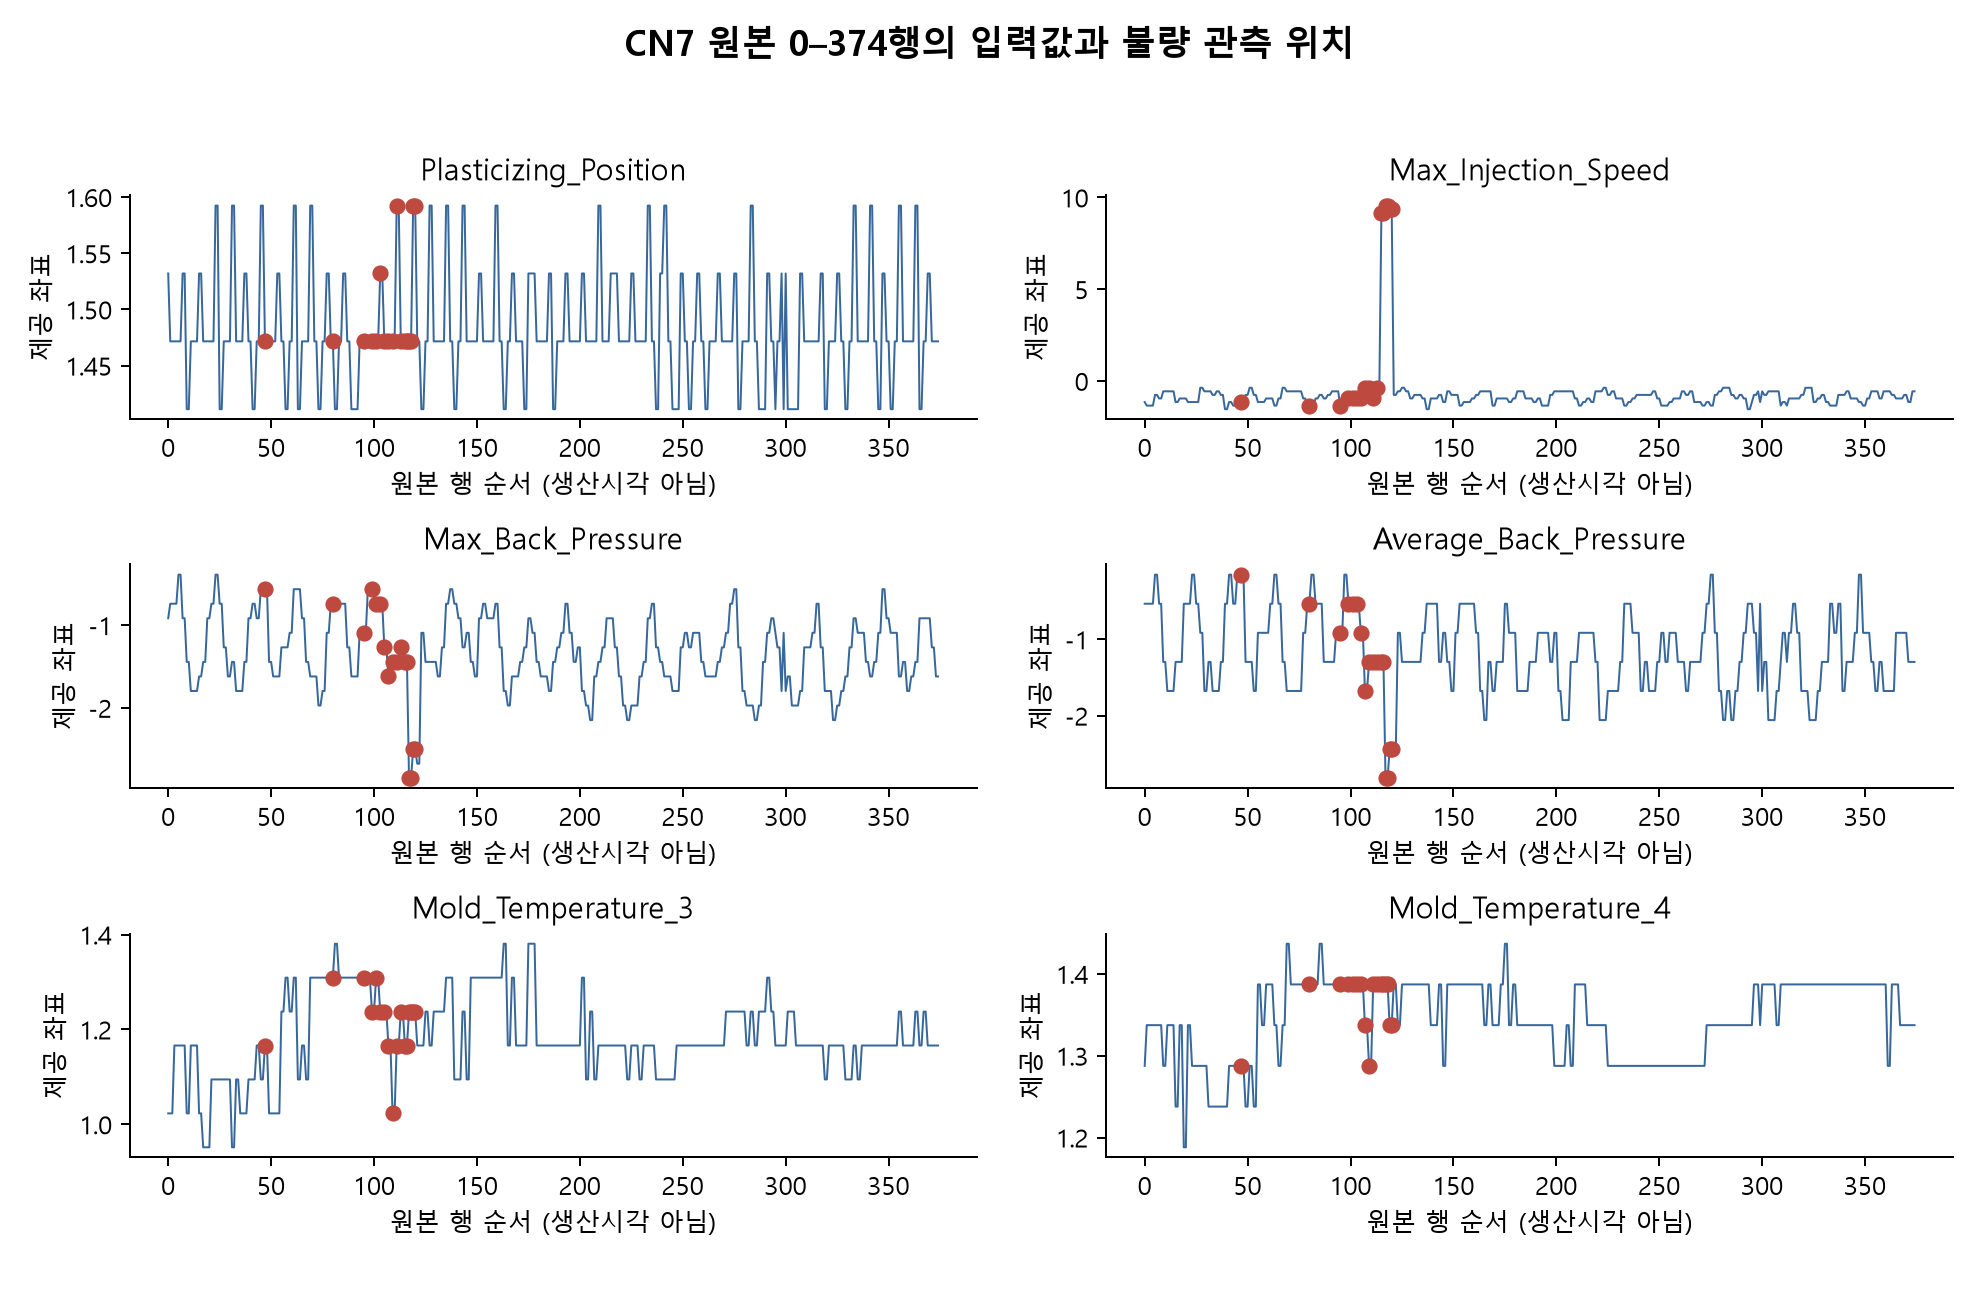

보고서 수록 그림: row_order_cn7


In [9]:
# 보고서용 시각화: 기존 학습 셀을 실행하지 않고 저장 결과를 표시한다.
from pathlib import Path
import sys
_report_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / "reporting/visualizations.py").is_file())
if str(_report_root) not in sys.path:
    sys.path.insert(0, str(_report_root))
from reporting.visualizations import show_notebook
_report_figure_ids = show_notebook('26kamp.ipynb')
print("보고서 수록 그림:", ", ".join(_report_figure_ids))
